**Tahap 1: Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import collections

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Memastikan Colab menggunakan GPU (T4) biar training super cepat
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan Device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan Device: cuda
Nama GPU: Tesla T4


**Tahap 2: Membaca Dataset dari Google Colab**

In [3]:
# Pastikan file 'dataset_clean_final.csv' sudah di-upload ke tab Files di kiri Colab
file_path = 'dataset_clean_final.csv'
df = pd.read_csv(file_path)

print(f"Berhasil memuat dataset! Total baris data: {len(df)}")

# Deteksi nama kolom secara otomatis
text_col = 'text' if 'text' in df.columns else ('comment' if 'comment' in df.columns else df.columns[0])
label_col = 'label' if 'label' in df.columns else df.columns[1]
print(f"Kolom teks yang digunakan: '{text_col}' | Kolom label: '{label_col}'")

# Hapus data kosong agar training tidak error
df = df.dropna(subset=[text_col, label_col])
df[label_col] = df[label_col].astype(int)

# Tampilkan 5 data teratas
df.head()

Berhasil memuat dataset! Total baris data: 29313
Kolom teks yang digunakan: 'text' | Kolom label: 'label'


,text,label
0,makin yakin habis baca review lain tentang vic...,1
1,paling suka model h2 smiling_face_with_heart e...,0
2,mobilnya sudah hancur pleading_face,0
3,manut88benar2 bikin aku jadi sultan,1
4,semoga lekas recover mobilnya mas dipo,0


**Tahap 3: Teks Preprocessing (Pembersihan Teks & Kamus Slang)**

In [4]:
SLANG_JUDOL_MAP = {
    'gacor': 'menang mudah',
    'wd': 'withdraw penarikan dana',
    'depo': 'deposit pengisian dana',
    'judol': 'judi online',
    's1ot': 'slot',
    'sl0t': 'slot',
    'jp': 'jackpot',
    'zeus': 'judi kakek zeus'
}

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Deteksi link/URL promosi situs judol dan ubah jadi kata penanda
    text = re.sub(r'https?://\S+|www\.\S+', 'link_website', text)
    # Hapus simbol dan karakter aneh
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Normalisasi kata slang/sandi judol
    words = text.split()
    normalized_words = [SLANG_JUDOL_MAP.get(word, word) for word in words]
    return " ".join(normalized_words)

# Terapkan pembersihan
df['cleaned_text'] = df[text_col].apply(clean_text)
print("Contoh hasil preprocessing:")
df[[text_col, 'cleaned_text']].head()

Contoh hasil preprocessing:


,text,cleaned_text
0,makin yakin habis baca review lain tentang vic...,makin yakin habis baca review lain tentang vic...
1,paling suka model h2 smiling_face_with_heart e...,paling suka model h2 smilingfacewithheart eyes...
2,mobilnya sudah hancur pleading_face,mobilnya sudah hancur pleadingface
3,manut88benar2 bikin aku jadi sultan,manut88benar2 bikin aku jadi sultan
4,semoga lekas recover mobilnya mas dipo,semoga lekas recover mobilnya mas dipo


**Tahap 4: Membuat Kamus Kata (Vocabulary) & Tokenisasi**

In [5]:
# Kumpulkan semua kata untuk membuat kamus
all_words = []
for text in df['cleaned_text']:
    all_words.extend(text.split())

# Buat Vocabulary (hanya mengambil kata yang muncul minimal 2 kali)
word_counts = collections.Counter(all_words)

vocab = {}
vocab['<PAD>'] = 0  # Index 0
vocab['<UNK>'] = 1  # Index 1

for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab) # Otomatis mengisi index 2, 3, 4, dst secara urut

# Ambil total ukuran asli kamus kata kita
VOCAB_SIZE = len(vocab)
MAX_LEN = 50

print(f"Total kata unik dalam kamus (VOCAB_SIZE): {VOCAB_SIZE} kata")

def text_to_sequence(text, vocab, max_len):
    tokens = text.split()
    sequence = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    if len(sequence) < max_len:
        sequence = sequence + [vocab['<PAD>']] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

# Konversi seluruh teks menjadi barisan angka
X = np.array([text_to_sequence(txt, vocab, MAX_LEN) for txt in df['cleaned_text']])
y = df[label_col].values

print(f"Index angka tertinggi di dalam data X: {X.max()}")
print(f"Apakah index aman untuk dimasukkan ke model? {X.max() < VOCAB_SIZE} (Harus True)")

Total kata unik dalam kamus (VOCAB_SIZE): 12797 kata
Index angka tertinggi di dalam data X: 12796
Apakah index aman untuk dimasukkan ke model? True (Harus True)


**Tahap 5: Pembagian Dataset & Pembuatan DataLoader**

In [6]:
# Split Dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Data dipisah -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Custom Dataset PyTorch
class YouTubeCommentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Siapkan Dataloader untuk proses batching
train_loader = DataLoader(YouTubeCommentDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(YouTubeCommentDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(YouTubeCommentDataset(X_test, y_test), batch_size=64, shuffle=False)

Data dipisah -> Train: 20518 | Val: 4397 | Test: 4397


**Tahap 6: Membangun Struktur Arsitektur Model BiGRU**

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers=2, dropout=0.3):
        super(BiGRUClassifier, self).__init__()
        # Layer embedding menerima ukuran VOCAB_SIZE
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=num_layers,
                          bidirectional=True, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.gru(embedded)

        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        return self.fc(self.dropout(hidden_concat))

# Hyperparameter
EMBEDDING_DIM = 128
HIDDEN_DIM = 64

# Kita panggil model ke GPU setelah runtime di-reset bersih
model = BiGRUClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, output_dim=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model BiGRU sukses didaftarkan ke GPU/Device tanpa error!")

Model BiGRU sukses didaftarkan ke GPU/Device tanpa error!


**Tahap 7: Proses Training Model**

In [8]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    return (rounded_preds == y).float().sum() / len(rounded_preds)

EPOCHS = 5
print("--- Proses Training Dimulai ---")
for epoch in range(EPOCHS):
    model.train()
    train_loss, train_acc = 0, 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(seqs).squeeze(1)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += acc.item()

    # Evaluasi Validasi
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            predictions = model(seqs).squeeze(1)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)
            val_loss += loss.item()
            val_acc += acc.item()

    print(f"Epoch {epoch+1:02} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc/len(train_loader)*100:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc/len(val_loader)*100:.2f}%")
print("--- Training Selesai! ---")

--- Proses Training Dimulai ---
Epoch 01 | Train Loss: 0.2130 | Train Acc: 92.70% | Val Loss: 0.1046 | Val Acc: 96.97%
Epoch 02 | Train Loss: 0.0878 | Train Acc: 97.32% | Val Loss: 0.0614 | Val Acc: 98.42%
Epoch 03 | Train Loss: 0.0584 | Train Acc: 98.20% | Val Loss: 0.0616 | Val Acc: 98.54%
Epoch 04 | Train Loss: 0.0422 | Train Acc: 98.82% | Val Loss: 0.0498 | Val Acc: 98.75%
Epoch 05 | Train Loss: 0.0330 | Train Acc: 99.00% | Val Loss: 0.0460 | Val Acc: 98.82%
--- Training Selesai! ---


**Tahap 8: Evaluasi Akhir (Metrik Pengujian & Grafik Confusion Matrix)**


--- TEST DATA EVALUATION REPORT ---
              precision    recall  f1-score   support

 Bukan Judol       0.99      1.00      1.00      3837
       Judol       0.98      0.96      0.97       560

    accuracy                           0.99      4397
   macro avg       0.99      0.98      0.98      4397
weighted avg       0.99      0.99      0.99      4397



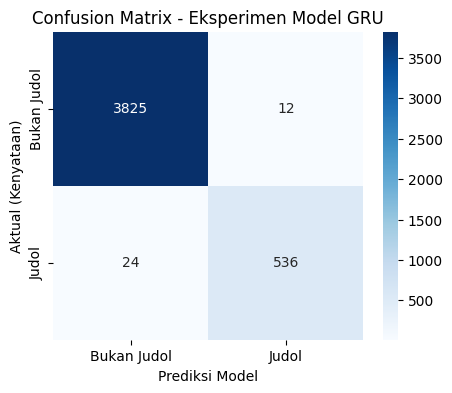

In [9]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(device)
        predictions = model(seqs).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- TEST DATA EVALUATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=['Bukan Judol', 'Judol']))

# Plotting Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bukan Judol', 'Judol'], yticklabels=['Bukan Judol', 'Judol'])
plt.ylabel('Aktual (Kenyataan)')
plt.xlabel('Prediksi Model')
plt.title('Confusion Matrix - Eksperimen Model GRU')
plt.show()

**Tahap 9: Pengujian Mandiri Secara Real-Time**

In [10]:
def predict_comment(text):
    model.eval()
    cleaned = clean_text(text)
    seq = text_to_sequence(cleaned, vocab, MAX_LEN)
    tensor_input = torch.tensor([seq], dtype=torch.long).to(device)
    with torch.no_grad():
        prediction = torch.sigmoid(model(tensor_input)).item()

    label_pred = "TERDETEKSI JUDOL" if prediction >= 0.5 else "AMAN (BUKAN JUDOL)"
    return label_pred, prediction

# Masukkan kalimat sesukamu di sini untuk menguji model
kalimat_uji = "Jangan lupa klaim bonus deposit pertama di situs zeus gampang menang hari ini!"
hasil, skor = predict_comment(kalimat_uji)

print(f"Teks Komentar: \"{kalimat_uji}\"")
print(f"Hasil Analisis Model: {hasil} (Confidence: {skor*100:.2f}%)")

Teks Komentar: "Jangan lupa klaim bonus deposit pertama di situs zeus gampang menang hari ini!"
Hasil Analisis Model: TERDETEKSI JUDOL (Confidence: 99.62%)
